In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import beta, norm
import stan
import nest_asyncio
nest_asyncio.apply()
import time
import arviz as az
import itertools

/home/tomas/.local/lib/python3.10/site-packages/matplotlib/projections/__init__.py:63: UserWarning: Unable to import Axes3D. This may be due to multiple versions of Matplotlib being installed (e.g. as a system package and as a pip package). As a result, the 3D projection is not available.
  warnings.warn("Unable to import Axes3D. This may be due to multiple versions of "
/home/tomas/.local/lib/python3.10/site-packages/scipy/__init__.py:146: UserWarning: A NumPy version >=1.16.5 and <1.23.0 is required for this version of SciPy (detected version 1.26.4
  warnings.warn(f"A NumPy version >={np_minversion} and <{np_maxversion}"


In [2]:
plt.rcParams['figure.figsize'] = [10,8]

In [3]:
# Distribution parameters
alpha_b = 6  # Beta distribution for 'b'
beta_param_b = 1.7
mu_c = 0.4  # Normal distribution for 'c'
sigma_c = 0.1
mu_j = 0.18  # Normal distribution for 'j'
sigma_j = 0.03


np.random.seed(4)

# Function to sample a score based on the individual component
def sample_score(component):
    if component == 'j':
        return np.random.normal(mu_j, sigma_j)
    elif component == 'c':
        return np.random.normal(mu_c, sigma_c)
    elif component == 'b':
        return np.random.beta(alpha_b, beta_param_b)
    else:
        raise ValueError(f"Unknown component: {component}")  #just in case

# Generate unique permutations
def unique_permutations(elements):
    return list(set(itertools.permutations(elements)))

# Generate the unique permutations
bbjj_permutations = unique_permutations(['b', 'b', 'j', 'j'])
ccbb_permutations = unique_permutations(['c', 'c', 'b', 'b'])
jjcc_permutations = unique_permutations(['j', 'j', 'c', 'c'])

#print(bbjj_permutations)

def generate_scores_with_labels(class_label):
    if class_label == 'jjjj':
        scores = [sample_score('j') for _ in range(4)]
        labels = ['j', 'j', 'j', 'j']
    elif class_label == 'bbbb':
        scores = [sample_score('b') for _ in range(4)]
        labels = ['b', 'b', 'b', 'b']
    elif class_label == 'cccc':
        scores = [sample_score('c') for _ in range(4)]
        labels = ['c', 'c', 'c', 'c']
    elif class_label == 'bbjj':
        perm = np.random.choice(len(bbjj_permutations))  # Select a unique permutation
        labels = bbjj_permutations[perm]
        scores = [sample_score(comp) for comp in labels]
    elif class_label == 'ccbb':
        perm = np.random.choice(len(ccbb_permutations))  # Select a unique permutation
        labels = ccbb_permutations[perm]
        scores = [sample_score(comp) for comp in labels]
    elif class_label in ['jjcc', 'ccjj']:  # Both use the same permutations
        perm = np.random.choice(len(jjcc_permutations))  # Select a unique permutation
        labels = jjcc_permutations[perm]
        scores = [sample_score(comp) for comp in labels]
    else:
        raise ValueError(f"Unknown class: {class_label}")  # just in case
    
    return scores, labels

# Generate classes based on the probabilities and sample the scores
N = 1000
classes = ["jjjj", "bbjj", "ccjj", "ccbb", "cccc", "bbbb"]
p = [0.8, 0.06, 0.05, 0.04, 0.03, 0.02]  # probabilities for each class
class_column = np.random.choice(classes, size=N, p=p)

data = []
for c in class_column:
    try:
        scores, labels = generate_scores_with_labels(c)
        data.append(scores + [c] + list(labels))  # Add scores, class, and labels
    except ValueError as e:
        print(e)  # just in case

# Create the DataFrame with the new label columns
df = pd.DataFrame(data, columns=['s1', 's2', 's3', 's4', 'class', 'label_s1', 'label_s2', 'label_s3', 'label_s4'])


df

,s1,s2,s3,s4,class,label_s1,label_s2,label_s3,label_s4
0,0.499302,0.553002,0.416955,0.406433,cccc,c,c,c,c
1,0.153468,0.150161,0.177024,0.216288,jjjj,j,j,j,j
2,0.373815,0.487571,0.440330,0.390246,cccc,c,c,c,c
3,0.155649,0.169359,0.144896,0.205669,jjjj,j,j,j,j
4,0.195350,0.151698,0.160482,0.141643,jjjj,j,j,j,j
...,...,...,...,...,...,...,...,...,...
995,0.162505,0.183860,0.177473,0.143331,jjjj,j,j,j,j
996,0.206325,0.178314,0.202880,0.186527,jjjj,j,j,j,j
997,0.373896,0.187375,0.157972,0.412830,ccjj,c,j,j,c
998,0.188461,0.200397,0.161234,0.199908,jjjj,j,j,j,j


In [4]:
df['label_s1'].value_counts()

label_s1
j    851
c     83
b     66
Name: count, dtype: int64

In [5]:
# Obtener el conteo de cada clase
class_counts = df['class'].value_counts()
print(class_counts)
# Calcular las fracciones dividiendo por el total N
class_fractions = class_counts / N

# Convertir a lista
class_fractions_list = class_fractions.tolist()

class_fractions_list_rounded = [round(fraction, 2) for fraction in class_fractions_list]
print('')
print(class_fractions_list_rounded,'data fraction')
print(p,'true fraction')

class
jjjj    795
ccjj     57
bbjj     52
ccbb     44
cccc     35
bbbb     17
Name: count, dtype: int64

[0.8, 0.06, 0.05, 0.04, 0.04, 0.02] data fraction
[0.8, 0.06, 0.05, 0.04, 0.03, 0.02] true fraction


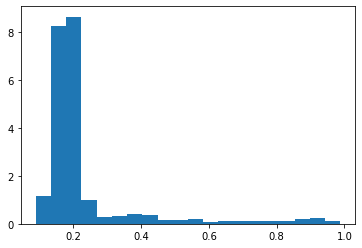

In [6]:
plt.figure()
plt.hist(df['s1'],bins=20,density=True)
plt.show()

In [7]:
m = 20

# Function to rescale values to the interval [1, m] and convert to integers
def rescale_to_interval(values, m):
    return np.round(values * (m - 1) + 1).astype(int)

# Create a copy of the original DataFrame
df_rescaled = df.copy()

# Apply rescaling to each score column in the new DataFrame
df_rescaled['s1'] = rescale_to_interval(df_rescaled['s1'], m)
df_rescaled['s2'] = rescale_to_interval(df_rescaled['s2'], m)
df_rescaled['s3'] = rescale_to_interval(df_rescaled['s3'], m)
df_rescaled['s4'] = rescale_to_interval(df_rescaled['s4'], m)

# Display the rescaled DataFrame
print(df_rescaled.head())

# Show the value counts for the class column in the rescaled DataFrame
print(df_rescaled['class'].value_counts())

# Check the total number of rows in the rescaled DataFrame
print(len(df_rescaled))


   s1  s2  s3  s4 class label_s1 label_s2 label_s3 label_s4
0  10  12   9   9  cccc        c        c        c        c
1   4   4   4   5  jjjj        j        j        j        j
2   8  10   9   8  cccc        c        c        c        c
3   4   4   4   5  jjjj        j        j        j        j
4   5   4   4   4  jjjj        j        j        j        j
class
jjjj    795
ccjj     57
bbjj     52
ccbb     44
cccc     35
bbbb     17
Name: count, dtype: int64
1000


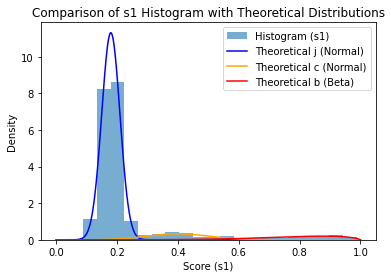

In [10]:
plt.figure()
# Values for the x-axis
x = np.linspace(0, 1, 1000)  # Range of possible values for s1

# Theoretical distributions
pdf_j = norm.pdf(x, mu_j, sigma_j)  # Normal distribution for 'j'
pdf_c = norm.pdf(x, mu_c, sigma_c)  # Normal distribution for 'c'
pdf_b = beta.pdf(x, alpha_b, beta_param_b)  # Beta distribution for 'b'

# Plot the histogram of s1
plt.hist(df['s1'], bins=20, density=True, alpha=0.6, label='Histogram (s1)')

# Plot the theoretical distributions
plt.plot(x, pdf_j*df['label_s1'].value_counts()['j']/N, label='Theoretical j (Normal)', color='blue')
plt.plot(x, pdf_c*df['label_s1'].value_counts()['c']/N, label='Theoretical c (Normal)', color='orange')
plt.plot(x, pdf_b*df['label_s1'].value_counts()['b']/N, label='Theoretical b (Beta)', color='red')

# Add labels and legend
plt.xlabel('Score (s1)')
plt.ylabel('Density')
plt.legend()
plt.title('Comparison of s1 Histogram with Theoretical Distributions')

# Show the plot
plt.show()

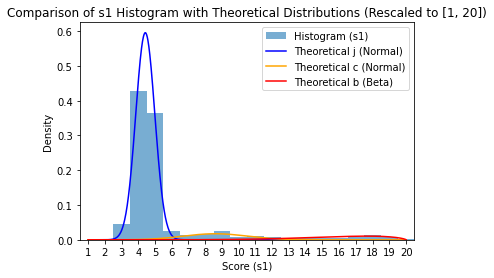

In [11]:
plt.figure()
# Valores del eje x reescalados a [1, m]
x_rescaled = np.linspace(1, m, 1000)  # Rango de valores posibles para s1

# Ajustar las distribuciones teóricas a [1, m]
pdf_j_rescaled = norm.pdf((x_rescaled - 1) / (m - 1), mu_j, sigma_j) / (m - 1)  # Normal para 'j' reescalada
pdf_c_rescaled = norm.pdf((x_rescaled - 1) / (m - 1), mu_c, sigma_c) / (m - 1)  # Normal para 'c' reescalada
pdf_b_rescaled = beta.pdf((x_rescaled - 1) / (m - 1), alpha_b, beta_param_b) / (m - 1)  # Beta para 'b' reescalada

bin_edges = np.arange(0.5, m + 1.5, 1)
# Graficar el histograma de s1 reescalado
plt.hist(df_rescaled['s1'], bins=bin_edges, density=True, alpha=0.6, label='Histogram (s1)')

# Graficar las distribuciones teóricas reescaladas
plt.plot(x_rescaled, pdf_j_rescaled * df['label_s1'].value_counts()['j'] / N, label='Theoretical j (Normal)', color='blue')
plt.plot(x_rescaled, pdf_c_rescaled * df['label_s1'].value_counts()['c'] / N, label='Theoretical c (Normal)', color='orange')
plt.plot(x_rescaled, pdf_b_rescaled * df['label_s1'].value_counts()['b'] / N, label='Theoretical b (Beta)', color='red')

# Añadir etiquetas y leyenda
plt.xlabel('Score (s1)')
plt.ylabel('Density')
plt.legend()
plt.xlim(0.5,m+0.5)
plt.title(f'Comparison of s1 Histogram with Theoretical Distributions (Rescaled to [1, {m}])')
plt.xticks(range(1,m+1))
# Mostrar el gráfico
plt.show()


In [12]:
score = df_rescaled[['s1', 's2', 's3', 's4']].values.tolist()
print(score[:3])
print(len(score))

[[10, 12, 9, 9], [4, 4, 4, 5], [8, 10, 9, 8]]
1000


In [13]:
my_mixture_4d = """
functions {
  real partial_sum(array[,] int score_slice,
                   int start, int end,
                   vector yj,
                   vector yb,
                   vector yc,
                   vector theta)
  {
    real permutation_factor = 1.0/6;
    real partial_target = 0;
    
    vector[6] lp;   // Six distinct classes: jjjj, bbjj (+perm), bbbb, bbcc (+perm), jjcc (+perm), and cccc.
    vector[6] lp2;  // To handle permutations for bbjj
    vector[6] lp3;  // To handle permutations for bbcc
    vector[6] lp4;  // To handle permutations for jjcc.
    
    int slice_length = end - start + 1;

    //jjjj, bbjj, ccjj, ccbb, cccc, bbbb is the order of the classes
    for (k in 1:slice_length) {
      // Permutations for bbjj
      lp2[1] = log(permutation_factor) + log(yj)[score_slice[k,1]] + log(yj)[score_slice[k,2]] + log(yb)[score_slice[k,3]] + log(yb)[score_slice[k,4]];
      lp2[2] = log(permutation_factor) + log(yj)[score_slice[k,1]] + log(yb)[score_slice[k,2]] + log(yj)[score_slice[k,3]] + log(yb)[score_slice[k,4]];
      lp2[3] = log(permutation_factor) + log(yj)[score_slice[k,1]] + log(yb)[score_slice[k,2]] + log(yb)[score_slice[k,3]] + log(yj)[score_slice[k,4]];
      lp2[4] = log(permutation_factor) + log(yb)[score_slice[k,1]] + log(yj)[score_slice[k,2]] + log(yj)[score_slice[k,3]] + log(yb)[score_slice[k,4]];
      lp2[5] = log(permutation_factor) + log(yb)[score_slice[k,1]] + log(yj)[score_slice[k,2]] + log(yb)[score_slice[k,3]] + log(yj)[score_slice[k,4]];
      lp2[6] = log(permutation_factor) + log(yb)[score_slice[k,1]] + log(yb)[score_slice[k,2]] + log(yj)[score_slice[k,3]] + log(yj)[score_slice[k,4]];

      // Assign probabilities for the six classes
      lp[1] = log(yj)[score_slice[k,1]] + log(yj)[score_slice[k,2]] + log(yj)[score_slice[k,3]] + log(yj)[score_slice[k,4]]; // jjjj
      lp[2] = log_sum_exp(lp2);    // bbjj + permutations
      lp[6] = log(yb)[score_slice[k,1]] + log(yb)[score_slice[k,2]] + log(yb)[score_slice[k,3]] + log(yb)[score_slice[k,4]]; // bbbb

      // Permutations for bbcc
      lp3[1] = log(permutation_factor) + log(yb)[score_slice[k,1]] + log(yb)[score_slice[k,2]] + log(yc)[score_slice[k,3]] + log(yc)[score_slice[k,4]];
      lp3[2] = log(permutation_factor) + log(yb)[score_slice[k,1]] + log(yc)[score_slice[k,2]] + log(yb)[score_slice[k,3]] + log(yc)[score_slice[k,4]];
      lp3[3] = log(permutation_factor) + log(yb)[score_slice[k,1]] + log(yc)[score_slice[k,2]] + log(yc)[score_slice[k,3]] + log(yb)[score_slice[k,4]];
      lp3[4] = log(permutation_factor) + log(yc)[score_slice[k,1]] + log(yb)[score_slice[k,2]] + log(yb)[score_slice[k,3]] + log(yc)[score_slice[k,4]];
      lp3[5] = log(permutation_factor) + log(yc)[score_slice[k,1]] + log(yb)[score_slice[k,2]] + log(yc)[score_slice[k,3]] + log(yb)[score_slice[k,4]];
      lp3[6] = log(permutation_factor) + log(yc)[score_slice[k,1]] + log(yc)[score_slice[k,2]] + log(yb)[score_slice[k,3]] + log(yb)[score_slice[k,4]];
      lp[4] = log_sum_exp(lp3);    // bbcc + permutations

      // Permutations for jjcc
      lp4[1] = log(permutation_factor) + log(yj)[score_slice[k,1]] + log(yj)[score_slice[k,2]] + log(yc)[score_slice[k,3]] + log(yc)[score_slice[k,4]];
      lp4[2] = log(permutation_factor) + log(yj)[score_slice[k,1]] + log(yc)[score_slice[k,2]] + log(yj)[score_slice[k,3]] + log(yc)[score_slice[k,4]];
      lp4[3] = log(permutation_factor) + log(yj)[score_slice[k,1]] + log(yc)[score_slice[k,2]] + log(yc)[score_slice[k,3]] + log(yj)[score_slice[k,4]];
      lp4[4] = log(permutation_factor) + log(yc)[score_slice[k,1]] + log(yj)[score_slice[k,2]] + log(yj)[score_slice[k,3]] + log(yc)[score_slice[k,4]];
      lp4[5] = log(permutation_factor) + log(yc)[score_slice[k,1]] + log(yj)[score_slice[k,2]] + log(yc)[score_slice[k,3]] + log(yj)[score_slice[k,4]];
      lp4[6] = log(permutation_factor) + log(yc)[score_slice[k,1]] + log(yc)[score_slice[k,2]] + log(yj)[score_slice[k,3]] + log(yj)[score_slice[k,4]];
      lp[3] = log_sum_exp(lp4);    // jjcc + permutations

      lp[5] = log(yc)[score_slice[k,1]] + log(yc)[score_slice[k,2]] + log(yc)[score_slice[k,3]] + log(yc)[score_slice[k,4]]; // cccc

      partial_target += log_mix(theta, lp);
    }

    return partial_target;
  }
}

data {
  int<lower=1> m;  // steps in the discretization
  int<lower=1> N;  // data points
  array[N,4] int<lower=1, upper=m> score;  // b-tagging score for jet#1
}

parameters {
  simplex[6] theta;  // Mixture coefficients of 6 classes as a simplex
  
  simplex[m] w_j_mode;  // Dirichlet weights for the background (jjjj and permutations)
  vector<lower=0>[m-1] a_j;  // Normal parameters for background
  
  simplex[m] w_b_mode;  // Dirichlet weights for the signal (bbbb and permutations)
  vector<lower=0>[m-1] a_b;  // Normal parameters for signal
  
  simplex[m] w_c_mode;  // Dirichlet weights for component c (cccc and permutations)
  vector<lower=0>[m-1] a_c;  // Normal parameters for component c
}

transformed parameters {
  ordered[2] y_label_switch_1;
  ordered[2] y_label_switch_2;
  ordered[2] y_label_switch_3;
  ordered[2] y_label_switch_4;
  ordered[2] y_label_switch_5;
  ordered[2] y_label_switch_6;
  ordered[2] y_label_switch_7;

  vector[m] p_j;  // Approximate distribution for j
  vector[m-1] sign_j;  // Signs for combination
  vector[m] logp_j;  // Log-probabilities
  
  sign_j = rep_vector(-1.0, m-1);
  p_j = rep_vector(0.0, m);

  for (k in 1:m) {
    if (k > 1) {
      for (j in 1:(k-1)) {
        sign_j[j] = 1.0;
      }
    }
    logp_j[1] = 0.0;
    for (j in 2:m) {
      logp_j[j] = logp_j[j-1] + sign_j[j-1] * a_j[j-1];
    }
    p_j += softmax(logp_j) * w_j_mode[k];
  }

  vector[m] p_b;  // Approximate distribution for b
  vector[m-1] sign_b;  // Signs for combination
  vector[m] logp_b;  // Log-probabilities

  sign_b = rep_vector(-1.0, m-1);
  p_b = rep_vector(0.0, m);

  for (k in 1:m) {
    if (k > 1) {
      for (j in 1:(k-1)) {
        sign_b[j] = 1.0;
      }
    }
    logp_b[1] = 0.0;
    for (j in 2:m) {
      logp_b[j] = logp_b[j-1] + sign_b[j-1] * a_b[j-1];
    }
    p_b += softmax(logp_b) * w_b_mode[k];
  }
  
  vector[m] p_c;  // Approximate distribution for c
  vector[m-1] sign_c;  // Signs for combination
  vector[m] logp_c;  // Log-probabilities
  
  sign_c = rep_vector(-1.0, m-1);
  p_c = rep_vector(0.0, m);

  for (k in 1:m) {
    if (k > 1) {
      for (j in 1:(k-1)) {
        sign_c[j] = 1.0;
      }
    }
    logp_c[1] = 0.0;
    for (j in 2:m) {
      logp_c[j] = logp_c[j-1] + sign_c[j-1] * a_c[j-1];
    }
    p_c += softmax(logp_c) * w_c_mode[k];
  }

  y_label_switch_1[1] = p_c[5];
  y_label_switch_1[2] = p_j[5];
  
  y_label_switch_2[1] = p_c[4];
  y_label_switch_2[2] = p_j[4];
  
  y_label_switch_3[1] = p_b[5];
  y_label_switch_3[2] = p_j[5];

  y_label_switch_4[1] = p_b[8];
  y_label_switch_4[2] = p_c[8];

  y_label_switch_5[1] = p_j[8];
  y_label_switch_5[2] = p_c[8];
  
  y_label_switch_6[1] = p_c[16];
  y_label_switch_6[2] = p_b[16];

  y_label_switch_7[1] = p_j[16];
  y_label_switch_7[2] = p_b[16];
  



}

model {
  int grainsize = 1;  // Adjust for parallel performance

  // Priors
  theta ~ dirichlet(rep_vector(1.0, 6));

  a_j ~ normal(0, 0.5);
  a_b ~ normal(0, 0.5);
  a_c ~ normal(0, 0.5);

  w_j_mode ~ dirichlet(rep_vector(1.0, m));
  w_b_mode ~ dirichlet(rep_vector(1.0, m));
  w_c_mode ~ dirichlet(rep_vector(1.0, m));

  target += reduce_sum(partial_sum, score, grainsize, p_j, p_b, p_c, theta);
}

"""

In [14]:
# Start the timer
start_time_4d = time.time()

# Build and sample from the 2D mixture model
model_4d = stan.build(my_mixture_4d, data={'m': m, 'N': len(score), 'score':score},random_seed=33)
fit_4d = model_4d.sample(num_chains=4, num_samples=1000, num_warmup = 1000)
df_4d = fit_4d.to_frame()

# Stop the timer
end_time_4d = time.time()

# Calculate the elapsed time
elapsed_time_4d = end_time_4d - start_time_4d

# Print the elapsed time
print(f"Time taken to run the 2D model: {elapsed_time_4d:.2f} seconds")


Building: 0.2s
Building: 0.3s
Building: 0.4s
Building: 0.5s
Building: 0.6s
Building: 0.7s
Building: 0.8s
Building: 0.9s
Building: 1.0s
Building: 1.1s
Building: 1.2s
Building: 1.3s
Building: 1.4s
Building: 1.5s
Building: 1.6s
Building: 1.7s
Building: 1.8s
Building: 1.9s
Building: 2.0s
Building: 2.1s
Building: 2.2s
Building: 2.3s
Building: 2.4s
Building: 2.5s
Building: 2.6s
Building: 2.7s
Building: 2.8s
Building: 2.9s
Building: 3.0s
Building: 3.1s
Building: 3.2s
Building: 3.3s
Building: 3.4s
Building: 3.5s
Building: 3.6s
Building: 3.7s
Building: 3.8s
Building: 3.9s
Building: 4.0s
Building: 4.1s
Building: 4.2s
Building: 4.3s
Building: 4.4s
Building: 4.5s
Building: 4.6s
Building: 4.7s
Building: 4.8s
Building: 4.9s
Building: 5.0s


In file included from /home/tomas/.local/lib/python3.10/site-packages/httpstan/include/tbb/concurrent_unordered_map.h:26,
                 from /home/tomas/.local/lib/python3.10/site-packages/httpstan/include/stan/math/rev/core/profiling.hpp:10,
                 from /home/tomas/.local/lib/python3.10/site-packages/httpstan/include/stan/math/rev/core.hpp:53,
                 from /home/tomas/.local/lib/python3.10/site-packages/httpstan/include/stan/math/rev.hpp:10,
                 from /home/tomas/.local/lib/python3.10/site-packages/httpstan/include/stan/math.hpp:19,
                 from /home/tomas/.local/lib/python3.10/site-packages/httpstan/include/stan/model/model_header.hpp:4,
                 from /home/tomas/.cache/httpstan/4.13.0/models/el7jghjj/model_el7jghjj.cpp:2:
/home/tomas/.local/lib/python3.10/site-packages/httpstan/include/tbb/internal/_concurrent_unordered_impl.h: In instantiation of ‘void tbb::interface5::internal::concurrent_unordered_base<Traits>::internal_init() [

Building: 5.1s
Building: 5.2s
Building: 5.3s
Building: 5.4s
Building: 5.5s
Building: 5.6s
Building: 5.7s
Building: 5.8s
Building: 6.0s
Building: 6.1s
Building: 6.2s
Building: 6.3s
Building: 6.4s
Building: 6.5s
Building: 6.6s
Building: 6.7s
Building: 6.8s
Building: 6.9s
Building: 7.0s
Building: 7.1s
Building: 7.2s
Building: 7.3s
Building: 7.4s
Building: 7.5s
Building: 7.6s
Building: 7.7s
Building: 7.8s
Building: 7.9s
Building: 8.0s
Building: 8.1s
Building: 8.2s
Building: 8.3s
Building: 8.4s
Building: 8.5s
Building: 8.6s
Building: 8.7s
Building: 8.8s
Building: 8.9s
Building: 9.0s
Building: 9.1s
Building: 9.2s
Building: 9.3s
Building: 9.4s
Building: 9.5s
Building: 9.6s
Building: 9.7s
Building: 9.8s
Building: 9.9s
Building: 10.0s
Building: 10.1s
Building: 10.2s
Building: 10.3s
Building: 10.4s
Building: 10.5s
Building: 10.6s
Building: 10.7s
Building: 10.8s
Building: 10.9s
Building: 11.0s
Building: 11.1s
Building: 11.2s
Building: 11.3s
Building: 11.4s
Building: 11.5s
Building: 11.6s
Building

Building: 18.5s, done.
Messages from stanc:
Warning in '/tmp/httpstan_d9z8nq7d/model_el7jghjj.stan', line 190, column 12: The
    variable partial_sum may not have been assigned a value before its use.
Sampling:   0%
Sampling:   0% (1/8000)
Sampling:   0% (2/8000)
Sampling:   0% (3/8000)
Sampling:   0% (4/8000)
Sampling:   1% (103/8000)
Sampling:   3% (203/8000)
Sampling:   4% (303/8000)
Sampling:   5% (402/8000)
Sampling:   6% (501/8000)
Sampling:   8% (600/8000)
Sampling:   9% (700/8000)
Sampling:  10% (800/8000)
Sampling:  11% (900/8000)
Sampling:  12% (1000/8000)
Sampling:  14% (1100/8000)
Sampling:  15% (1200/8000)
Sampling:  16% (1300/8000)
Sampling:  18% (1400/8000)
Sampling:  19% (1500/8000)
Sampling:  20% (1600/8000)
Sampling:  21% (1700/8000)
Sampling:  22% (1800/8000)
Sampling:  24% (1900/8000)
Sampling:  25% (2000/8000)
Sampling:  26% (2100/8000)
Sampling:  28% (2200/8000)
Sampling:  29% (2300/8000)
Sampling:  30% (2400/8000)
Sampling:  31% (2500/8000)
Sampling:  32% (2600/

warn:Rejecting initial value:
warn:  Error evaluating the log probability at the initial value.
warn:Exception: model_el7jghjj_namespace::log_prob: y_label_switch_6 is not a valid ordered vector. The element at 2 is 0.0278781, but should be greater than the previous element, 0.0525328 (in '/tmp/httpstan_qyc02lry/model_el7jghjj.stan', line 87, column 2 to column 30)
warn:Rejecting initial value:
warn:  Error evaluating the log probability at the initial value.
warn:Exception: model_el7jghjj_namespace::log_prob: y_label_switch_1 is not a valid ordered vector. The element at 2 is 0.0374043, but should be greater than the previous element, 0.133818 (in '/tmp/httpstan_qyc02lry/model_el7jghjj.stan', line 82, column 2 to column 30)
warn:Rejecting initial value:
warn:  Error evaluating the log probability at the initial value.
warn:Exception: model_el7jghjj_namespace::log_prob: y_label_switch_3 is not a valid ordered vector. The element at 2 is 0.0850648, but should be greater than the previou

...

  Informational Message: The current Metropolis proposal is about to be rejected because of the following issue:
  Exception: model_el7jghjj_namespace::log_prob: y_label_switch_4 is not a valid ordered vector. The element at 2 is 0.0574464, but should be greater than the previous element, 0.057457 (in '/tmp/httpstan_qyc02lry/model_el7jghjj.stan', line 85, column 2 to column 30)
  If this warning occurs sporadically, such as for highly constrained variable types like covariance matrices, then the sampler is fine,
  but if this warning occurs often then your model may be either severely ill-conditioned or misspecified.
  Informational Message: The current Metropolis proposal is about to be rejected because of the following issue:
  Exception: model_el7jghjj_namespace::log_prob: y_label_switch_4 is not a valid ordered vector. The element at 2 is 0.0575951, but should be greater than the previous element, 0.0576206 (in '/tmp/httpstan_qyc02lry/model_el7jghjj.stan', line 85, column 2 to colu

  Exception: model_el7jghjj_namespace::log_prob: y_label_switch_4 is not a valid ordered vector. The element at 2 is 0.0570852, but should be greater than the previous element, 0.0572993 (in '/tmp/httpstan_qyc02lry/model_el7jghjj.stan', line 85, column 2 to column 30)
  If this warning occurs sporadically, such as for highly constrained variable types like covariance matrices, then the sampler is fine,
  but if this warning occurs often then your model may be either severely ill-conditioned or misspecified.
  Informational Message: The current Metropolis proposal is about to be rejected because of the following issue:
  Exception: model_el7jghjj_namespace::log_prob: y_label_switch_4 is not a valid ordered vector. The element at 2 is 0.0575979, but should be greater than the previous element, 0.0576157 (in '/tmp/httpstan_qyc02lry/model_el7jghjj.stan', line 85, column 2 to column 30)
  If this warning occurs sporadically, such as for highly constrained variable types like covariance matr

  If this warning occurs sporadically, such as for highly constrained variable types like covariance matrices, then the sampler is fine,
  but if this warning occurs often then your model may be either severely ill-conditioned or misspecified.
  Informational Message: The current Metropolis proposal is about to be rejected because of the following issue:
  Exception: model_el7jghjj_namespace::log_prob: y_label_switch_4 is not a valid ordered vector. The element at 2 is 0.0572772, but should be greater than the previous element, 0.0573567 (in '/tmp/httpstan_qyc02lry/model_el7jghjj.stan', line 85, column 2 to column 30)
  If this warning occurs sporadically, such as for highly constrained variable types like covariance matrices, then the sampler is fine,
  but if this warning occurs often then your model may be either severely ill-conditioned or misspecified.
  Informational Message: The current Metropolis proposal is about to be rejected because of the following issue:
  Exception: mode

  but if this warning occurs often then your model may be either severely ill-conditioned or misspecified.
  Informational Message: The current Metropolis proposal is about to be rejected because of the following issue:
  Exception: model_el7jghjj_namespace::log_prob: y_label_switch_4 is not a valid ordered vector. The element at 2 is 0.0556421, but should be greater than the previous element, 0.0557447 (in '/tmp/httpstan_qyc02lry/model_el7jghjj.stan', line 85, column 2 to column 30)
  If this warning occurs sporadically, such as for highly constrained variable types like covariance matrices, then the sampler is fine,
  but if this warning occurs often then your model may be either severely ill-conditioned or misspecified.
  Informational Message: The current Metropolis proposal is about to be rejected because of the following issue:
  Exception: model_el7jghjj_namespace::log_prob: y_label_switch_4 is not a valid ordered vector. The element at 2 is 0.0555891, but should be greater than

Time taken to run the 2D model: 105.79 seconds


In [16]:
df_ordenado = df_4d.sort_values(by='lp__', ascending=False)  #ordeno por probabilidad
df_ordenado[:5]

parameters,lp__,accept_stat__,stepsize__,treedepth__,n_leapfrog__,divergent__,energy__,theta.1,theta.2,theta.3,...,logp_c.11,logp_c.12,logp_c.13,logp_c.14,logp_c.15,logp_c.16,logp_c.17,logp_c.18,logp_c.19,logp_c.20
draws,,,,,,,,,,,,,,,,,,,,,
2367,-6142.734269,0.976684,0.124014,5.0,31.0,0.0,6215.726506,0.806962,0.045083,0.058773,...,8.122592,9.426239,11.149698,11.537694,12.004839,12.215769,12.751426,13.103858,13.824294,14.582474
3476,-6144.921034,0.977672,0.127714,5.0,31.0,0.0,6208.117509,0.801557,0.047190,0.061123,...,7.382326,8.279888,9.365841,10.334734,10.765028,10.864857,11.658372,12.535555,13.050795,13.871468
813,-6148.176303,0.946113,0.143275,5.0,31.0,0.0,6206.248914,0.804001,0.056046,0.059019,...,7.243983,8.097937,9.889447,10.428759,10.770571,10.938859,11.726349,12.406354,12.935156,13.005882
555,-6149.490481,0.928125,0.124014,5.0,31.0,0.0,6203.800466,0.794719,0.047251,0.057247,...,6.326193,7.003165,8.959093,9.565646,10.349381,10.653270,11.267037,11.455391,11.754791,11.782150
1412,-6150.307309,0.801587,0.127714,5.0,31.0,0.0,6214.542761,0.824397,0.042467,0.044026,...,5.870942,6.879797,7.999469,8.296708,9.298864,9.530926,9.860641,10.057712,10.908135,11.258567


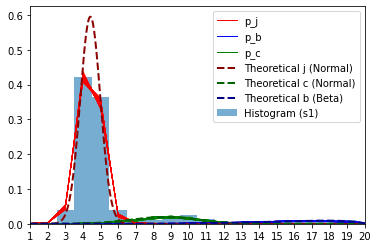

In [14]:
plt.figure()
m=20
#Normalizing and plotting inferred distributions
for i in range(500):
    # Extract the p_j and p_b values for the current sample
    p_j_values = np.array([df_ordenado.iloc[i]['p_j.' + str(x)] for x in range(1, 21)])
    p_b_values = np.array([df_ordenado.iloc[i]['p_b.' + str(x)] for x in range(1, 21)])
    p_c_values = np.array([df_ordenado.iloc[i]['p_c.' + str(x)] for x in range(1, 21)])
    
    # Plot the normalized curves
    if i == 0:   #actualy, the normalization factor is not known ? the proportion of j,b,c indiv. components.
        plt.plot(range(1, 21), p_j_values*df['label_s1'].value_counts()['j']/N, lw = 1,color='red', label='p_j')
        plt.plot(range(1, 21), p_b_values*df['label_s1'].value_counts()['b']/N, lw = 1,color='blue', label='p_b')
        plt.plot(range(1, 21), p_c_values*df['label_s1'].value_counts()['c']/N, lw = 1,color='green', label='p_c')

    else:
        plt.plot(range(1, 21), p_j_values*df['label_s1'].value_counts()['j']/N, lw = 0.2,color='red')
        plt.plot(range(1, 21), p_b_values*df['label_s1'].value_counts()['b']/N, lw = 0.2,color='blue')
        plt.plot(range(1, 21), p_c_values*df['label_s1'].value_counts()['c']/N, lw = 0.2,color='green')


# Graficar las distribuciones teóricas reescaladas
plt.plot(x_rescaled, pdf_j_rescaled * df['label_s1'].value_counts()['j'] / N, label='Theoretical j (Normal)', ls='--', lw=2, color='darkred')
plt.plot(x_rescaled, pdf_c_rescaled * df['label_s1'].value_counts()['c'] / N, label='Theoretical c (Normal)', ls='--', lw=2, color='darkgreen')
plt.plot(x_rescaled, pdf_b_rescaled * df['label_s1'].value_counts()['b'] / N, label='Theoretical b (Beta)', ls='--', lw=2, color='darkblue')

plt.hist(df_rescaled['s1'], bins=bin_edges, density=True, alpha=0.6, label='Histogram (s1)')

plt.xticks(np.arange(1,m+1))
plt.xlim(1,m)
#plt.ylim(0,0.05) #hacemos zoom
plt.legend()
#plt.grid(alpha=0.5)
plt.show()


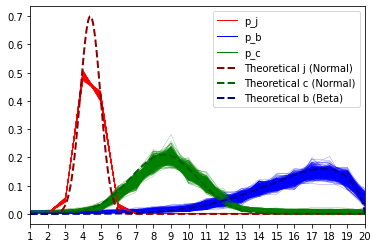

In [18]:
plt.figure()
m=20
#Normalizing and plotting inferred distributions
for i in range(500):
    # Extract the p_j and p_b values for the current sample
    p_j_values = np.array([df_ordenado.iloc[i]['p_j.' + str(x)] for x in range(1, 21)])
    p_b_values = np.array([df_ordenado.iloc[i]['p_b.' + str(x)] for x in range(1, 21)])
    p_c_values = np.array([df_ordenado.iloc[i]['p_c.' + str(x)] for x in range(1, 21)])
    
    # Plot the normalized curves
    if i == 0:   #actualy, the normalization factor is not known ? the proportion of j,b,c indiv. components.
        plt.plot(range(1, 21), p_j_values, lw = 1,color='red', label='p_j')
        plt.plot(range(1, 21), p_b_values, lw = 1,color='blue', label='p_b')
        plt.plot(range(1, 21), p_c_values, lw = 1,color='green', label='p_c')

    else:
        plt.plot(range(1, 21), p_j_values, lw = 0.2,color='red')
        plt.plot(range(1, 21), p_b_values, lw = 0.2,color='blue')
        plt.plot(range(1, 21), p_c_values, lw = 0.2,color='green')


# Graficar las distribuciones teóricas reescaladas
plt.plot(x_rescaled, pdf_j_rescaled, label='Theoretical j (Normal)', ls='--', lw=2, color='darkred')
plt.plot(x_rescaled, pdf_c_rescaled, label='Theoretical c (Normal)', ls='--', lw=2, color='darkgreen')
plt.plot(x_rescaled, pdf_b_rescaled, label='Theoretical b (Beta)', ls='--', lw=2, color='darkblue')

#plt.hist(df_rescaled['s1'], bins=bin_edges, density=True, alpha=0.6, label='Histogram (s1)')

plt.xticks(np.arange(1,m+1))
plt.xlim(1,m)
#plt.ylim(0,0.05) #hacemos zoom
plt.legend()
#plt.grid(alpha=0.5)
plt.show()


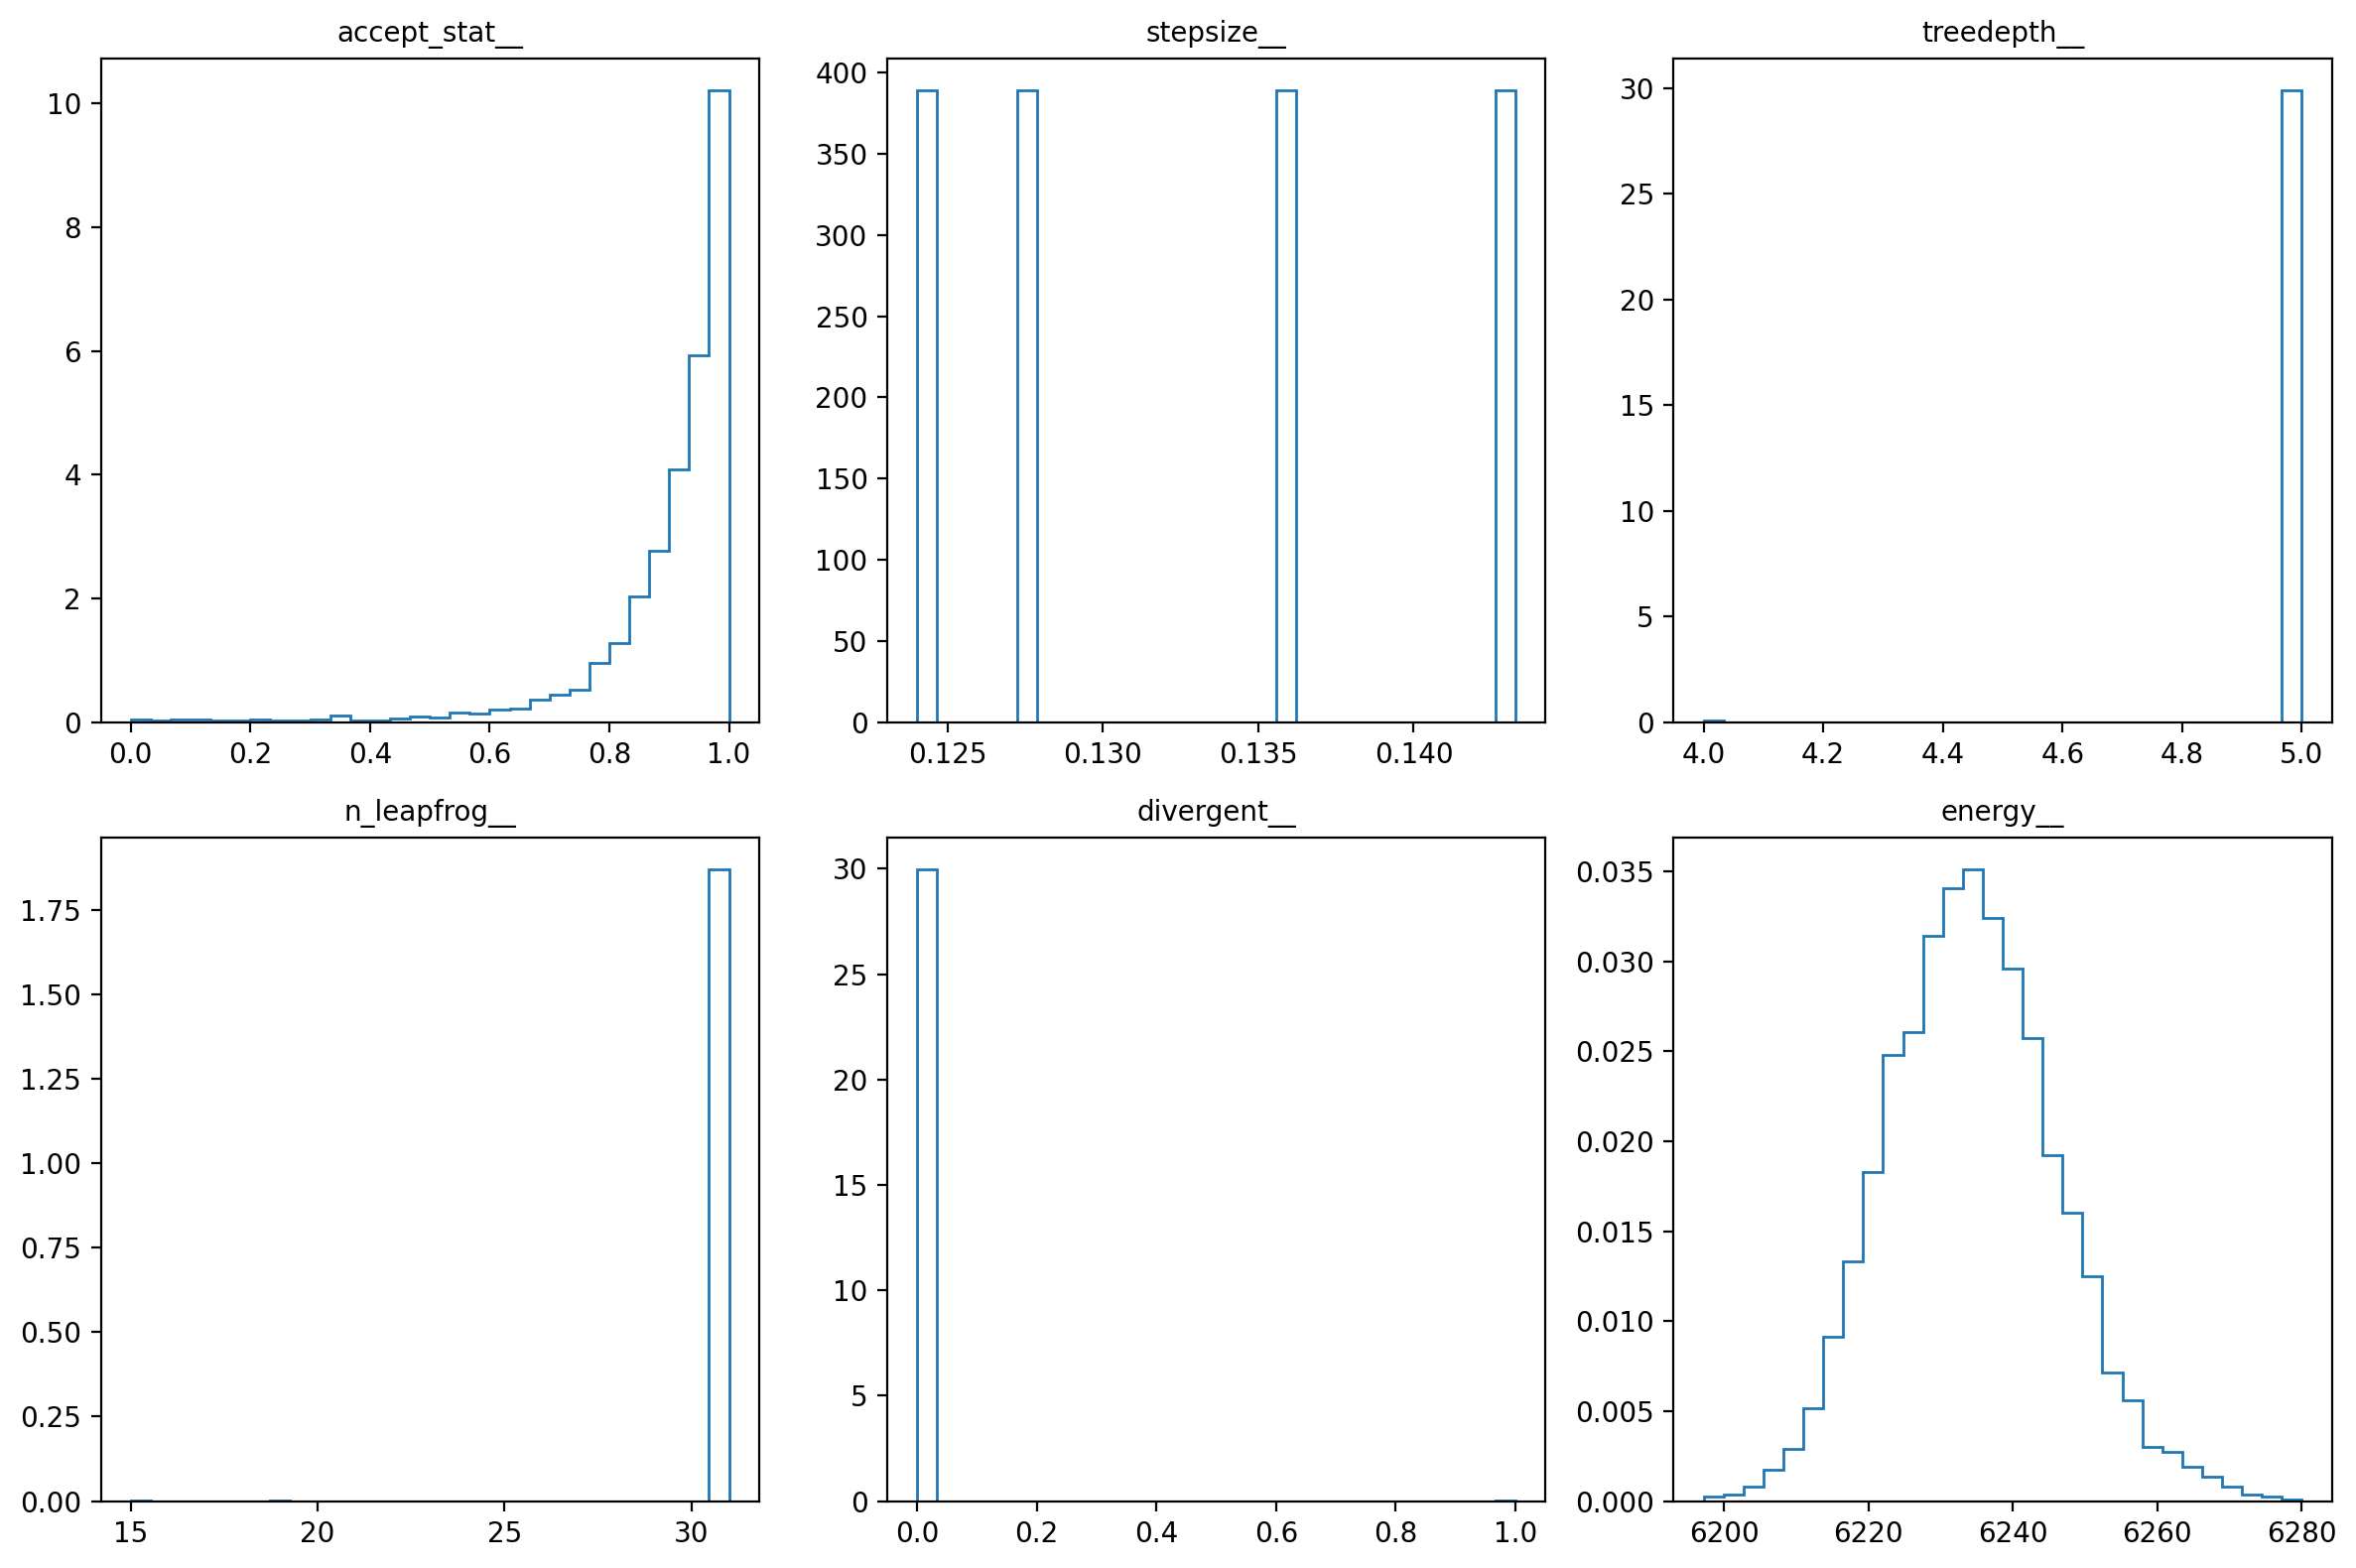

In [19]:
# Now define the posterior_4d with the relevant diagnostics columns
posterior_4d = df_4d[['accept_stat__', 'stepsize__', 'treedepth__', 'n_leapfrog__', 'divergent__', 'energy__']]

# Create subplots for each of the 6 diagnostic parameters
fig, axes = plt.subplots(2, 3, figsize=(12, 8), dpi=200)

# List of the diagnostic parameters
parameters = ['accept_stat__', 'stepsize__', 'treedepth__', 'n_leapfrog__', 'divergent__', 'energy__']

# Loop over the parameters and create histograms in subplots
for i, param in enumerate(parameters):
    row = i // 3  # Define the row for the subplot
    col = i % 3   # Define the column for the subplot
    axes[row, col].hist(posterior_4d[param], bins=30, histtype='step', density=True)
    axes[row, col].set_title(param, fontsize=10)

# Adjust layout to prevent overlap
plt.tight_layout()

# Show the plots
plt.show()


In [20]:
posterior = az.from_pystan(fit_4d)

# Get the ArviZ summary
summary_df = az.summary(posterior)

summary_df

/home/tomas/.local/lib/python3.10/site-packages/arviz/stats/diagnostics.py:596: RuntimeWarning: invalid value encountered in scalar divide
  (between_chain_variance / within_chain_variance + num_samples - 1) / (num_samples)
/home/tomas/.local/lib/python3.10/site-packages/arviz/stats/diagnostics.py:596: RuntimeWarning: invalid value encountered in scalar divide
  (between_chain_variance / within_chain_variance + num_samples - 1) / (num_samples)
/home/tomas/.local/lib/python3.10/site-packages/arviz/stats/diagnostics.py:596: RuntimeWarning: invalid value encountered in scalar divide
  (between_chain_variance / within_chain_variance + num_samples - 1) / (num_samples)


,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
theta[0],0.799,0.013,0.776,0.823,0.000,0.000,7510.0,3019.0,1.0
theta[1],0.049,0.007,0.035,0.063,0.000,0.000,6747.0,2852.0,1.0
theta[2],0.052,0.008,0.038,0.067,0.000,0.000,6837.0,3010.0,1.0
theta[3],0.041,0.007,0.028,0.055,0.000,0.000,7165.0,2925.0,1.0
theta[4],0.042,0.007,0.029,0.056,0.000,0.000,8588.0,3192.0,1.0
...,...,...,...,...,...,...,...,...,...
logp_c[15],10.751,1.009,8.872,12.605,0.015,0.010,4718.0,3468.0,1.0
logp_c[16],11.168,1.045,9.157,13.018,0.015,0.011,4809.0,3233.0,1.0
logp_c[17],11.575,1.083,9.687,13.711,0.016,0.011,4657.0,3826.0,1.0
logp_c[18],11.967,1.111,9.979,14.078,0.017,0.012,4429.0,3569.0,1.0


In [21]:
summary_df['r_hat'].values

array([ 1.,  1.,  1.,  1.,  1.,  1.,  1.,  1.,  1.,  1.,  1.,  1.,  1.,
        1.,  1.,  1.,  1.,  1.,  1.,  1.,  1.,  1.,  1.,  1.,  1.,  1.,
        1.,  1.,  1.,  1.,  1.,  1.,  1.,  1.,  1.,  1.,  1.,  1.,  1.,
        1.,  1.,  1.,  1.,  1.,  1.,  1.,  1.,  1.,  1.,  1.,  1.,  1.,
        1.,  1.,  1.,  1.,  1.,  1.,  1.,  1.,  1.,  1.,  1.,  1.,  1.,
        1.,  1.,  1.,  1.,  1.,  1.,  1.,  1.,  1.,  1.,  1.,  1.,  1.,
        1.,  1.,  1.,  1.,  1.,  1.,  1.,  1.,  1.,  1.,  1.,  1.,  1.,
        1.,  1.,  1.,  1.,  1.,  1.,  1.,  1.,  1.,  1.,  1.,  1.,  1.,
        1.,  1.,  1.,  1.,  1.,  1.,  1.,  1.,  1.,  1.,  1.,  1.,  1.,
        1.,  1.,  1.,  1.,  1.,  1.,  1.,  1.,  1.,  1.,  1.,  1.,  1.,
        1.,  1.,  1.,  1.,  1.,  1.,  1.,  1.,  1.,  1.,  1.,  1.,  1.,
        1.,  1.,  1.,  1.,  1.,  1.,  1.,  1.,  1.,  1.,  1.,  1.,  1.,
        1., nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan,
       nan, nan, nan, nan, nan, nan, nan, nan,  1.,  1.,  1.,  1

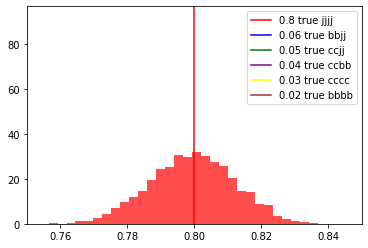

In [28]:
plt.figure()

plt.hist(df_4d['theta.1'],bins=30,alpha=0.7,density=True,color='red')
plt.axvline(p[0],color='red',label=f'{p[0]} true {classes[0]}')

plt.hist(df_4d['theta.2'],bins=30,alpha=0.7,density=True,color='blue')
plt.axvline(p[1],color='blue',label=f'{p[1]} true {classes[1]}')

plt.hist(df_4d['theta.3'],bins=30,alpha=0.7,density=True,color = 'green')
plt.axvline(p[2],color='green',label=f'{p[2]} true {classes[2]}')

plt.hist(df_4d['theta.4'],bins=30,alpha=0.7,density=True,color = 'purple')
plt.axvline(p[3],color='purple',label=f'{p[3]} true {classes[3]}')

plt.hist(df_4d['theta.5'],bins=30,alpha=0.7,density=True,color = 'yellow')
plt.axvline(p[4],color='yellow',label=f'{p[4]} true {classes[4]}')

plt.hist(df_4d['theta.6'],bins=30,alpha=0.7,density=True,color = 'brown')
plt.axvline(p[5],color='brown',label=f'{p[5]} true {classes[5]}')

plt.xlim(0.75,0.85)
plt.legend()
plt.show()

In [29]:
mydata = df_4d[['theta.1', 'theta.2', 'theta.3', 'theta.4', 'theta.5', 'theta.6']]   
mydata = np.round(mydata / 0.05) * 0.05
tmp = []
# Grid
values = np.linspace(0, 1, 21)
# Allow a small tolerance for rounding errors
tolerance = 1e-6

# Make the possible combinations of 6 numbers that sum approximately to 1
for i in values:
    for j in values:
        for k in values:
            for l in values:
                for m in values:
                    for n in values:
                        if abs(i + j + k + l + m + n - 1.0) < tolerance:
                            tmp.append([i, j, k, l, m, n])

total = len(mydata)
delta = 1/total
print(total, delta)
ternary_data = pd.DataFrame(tmp, columns=classes)
ternary_data['v'] = [0] * len(ternary_data)
ternary_data

4000 0.00025


,jjjj,bbjj,ccjj,ccbb,cccc,bbbb,v
0,0.00,0.00,0.00,0.00,0.00,1.00,0
1,0.00,0.00,0.00,0.00,0.05,0.95,0
2,0.00,0.00,0.00,0.00,0.10,0.90,0
3,0.00,0.00,0.00,0.00,0.15,0.85,0
4,0.00,0.00,0.00,0.00,0.20,0.80,0
...,...,...,...,...,...,...,...
53125,0.95,0.00,0.00,0.00,0.05,0.00,0
53126,0.95,0.00,0.00,0.05,0.00,0.00,0
53127,0.95,0.00,0.05,0.00,0.00,0.00,0
53128,0.95,0.05,0.00,0.00,0.00,0.00,0


In [30]:
ternary_data

,jjjj,bbjj,ccjj,ccbb,cccc,bbbb,v
0,0.00,0.00,0.00,0.00,0.00,1.00,0
1,0.00,0.00,0.00,0.00,0.05,0.95,0
2,0.00,0.00,0.00,0.00,0.10,0.90,0
3,0.00,0.00,0.00,0.00,0.15,0.85,0
4,0.00,0.00,0.00,0.00,0.20,0.80,0
...,...,...,...,...,...,...,...
53125,0.95,0.00,0.00,0.00,0.05,0.00,0
53126,0.95,0.00,0.00,0.05,0.00,0.00,0
53127,0.95,0.00,0.05,0.00,0.00,0.00,0
53128,0.95,0.05,0.00,0.00,0.00,0.00,0


In [31]:
# Encuentra las filas duplicadas en mydata
duplicated_rows = mydata[mydata.duplicated(keep=False)]

# Muestra todas las filas duplicadas
duplicated_rows

parameters,theta.1,theta.2,theta.3,theta.4,theta.5,theta.6
draws,,,,,,
0,0.8,0.05,0.05,0.05,0.05,0.0
1,0.8,0.05,0.05,0.05,0.05,0.0
2,0.8,0.05,0.05,0.05,0.05,0.0
3,0.8,0.05,0.05,0.05,0.05,0.0
4,0.8,0.05,0.05,0.05,0.05,0.0
...,...,...,...,...,...,...
3995,0.8,0.05,0.05,0.05,0.05,0.0
3996,0.8,0.05,0.05,0.05,0.05,0.0
3997,0.8,0.05,0.05,0.05,0.05,0.0


In [32]:
mydata['theta.6'].value_counts()

theta.6
0.00    3904
0.05      96
Name: count, dtype: int64

In [33]:
force_uniform = 5  #solo es distinto de 1 o no

if force_uniform != 1:
    for k in range(total):
        # Filtrar en ternary_data las filas que coincidan con los valores de mydata en todas las columnas
        mask = (
            (ternary_data[classes[0]] == mydata.iloc[k, 0]) &
            (ternary_data[classes[1]] == mydata.iloc[k, 1]) &
            (ternary_data[classes[2]] == mydata.iloc[k, 2]) &
            (ternary_data[classes[3]] == mydata.iloc[k, 3]) &
            (ternary_data[classes[4]] == mydata.iloc[k, 4]) &
            (ternary_data[classes[5]] == mydata.iloc[k, 5])
        )
        # Incrementar la probabilidad 'v' en las filas correspondientes
        ternary_data.loc[mask, 'v'] += delta
else:
    # Si se fuerza la distribución uniforme, se asigna una probabilidad uniforme a todos los puntos
    ternary_data['v'] = [1 / len(ternary_data)] * len(ternary_data)

    
ternary_data

/tmp/ipykernel_1179192/4268035911.py:15: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '[0.00025]' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  ternary_data.loc[mask, 'v'] += delta


,jjjj,bbjj,ccjj,ccbb,cccc,bbbb,v
0,0.00,0.00,0.00,0.00,0.00,1.00,0.0
1,0.00,0.00,0.00,0.00,0.05,0.95,0.0
2,0.00,0.00,0.00,0.00,0.10,0.90,0.0
3,0.00,0.00,0.00,0.00,0.15,0.85,0.0
4,0.00,0.00,0.00,0.00,0.20,0.80,0.0
...,...,...,...,...,...,...,...
53125,0.95,0.00,0.00,0.00,0.05,0.00,0.0
53126,0.95,0.00,0.00,0.05,0.00,0.00,0.0
53127,0.95,0.00,0.05,0.00,0.00,0.00,0.0
53128,0.95,0.05,0.00,0.00,0.00,0.00,0.0


In [34]:
ternary_data['v'].value_counts()

v
0.00000    53123
0.00100        2
0.00075        2
0.00225        1
0.00025        1
0.91925        1
Name: count, dtype: int64

In [35]:
ternary_data.loc[ternary_data['v'].idxmax()]

jjjj    0.80000
bbjj    0.05000
ccjj    0.05000
ccbb    0.05000
cccc    0.05000
bbbb    0.00000
v       0.91925
Name: 53053, dtype: float64

In [36]:
p, classes  #remember true values

([0.8, 0.06, 0.05, 0.04, 0.03, 0.02],
 ['jjjj', 'bbjj', 'ccjj', 'ccbb', 'cccc', 'bbbb'])

In [37]:
p_rounded = np.round(np.array(p) / 0.05) * 0.05
p_rounded

array([0.8 , 0.05, 0.05, 0.05, 0.05, 0.  ])

In [38]:
# Filtros por cada clase y valor correspondiente
mask = (
    (ternary_data[classes[0]] == p_rounded[0]) &
    (ternary_data[classes[1]] == p_rounded[1]) &
    (ternary_data[classes[2]] == p_rounded[2]) &
    (ternary_data[classes[3]] == p_rounded[3]) &
    (ternary_data[classes[4]] == p_rounded[4]) &
    (ternary_data[classes[5]] == p_rounded[5])
)

# Extraer el valor 'v' y redondearlo

prob_true = np.round(ternary_data[mask]['v'].values[0],3)
prob_true, delta, prob_true/delta

(0.919, 0.00025, 3676.0)

In [39]:
mean1 = np.average(ternary_data[classes[0]], weights=ternary_data['v'])
mean2 = np.average(ternary_data[classes[1]], weights=ternary_data['v'])
mean3 = np.average(ternary_data[classes[2]], weights=ternary_data['v'])
mean4 = np.average(ternary_data[classes[3]], weights=ternary_data['v'])
mean5 = np.average(ternary_data[classes[4]], weights=ternary_data['v'])
mean6 = np.average(ternary_data[classes[5]], weights=ternary_data['v'])

fraction_mean = np.array([mean1, mean2, mean3, mean4, mean5, mean6])

distance = np.round(np.linalg.norm(fraction_mean - np.array(p)),3)

print('classes:', classes,'\nfraction mean:', np.round(fraction_mean,3),'\nReal fracion:', p, '\nAbsolute distance:',distance,'\ndelta:',delta,'-->','prob_true:',prob_true,', increase factor:',prob_true/delta)

classes: ['jjjj', 'bbjj', 'ccjj', 'ccbb', 'cccc', 'bbbb'] 
fraction mean: [0.8  0.05 0.05 0.05 0.05 0.  ] 
Real fracion: [0.8, 0.06, 0.05, 0.04, 0.03, 0.02] 
Absolute distance: 0.032 
delta: 0.00025 --> prob_true: 0.919 , increase factor: 3676.0


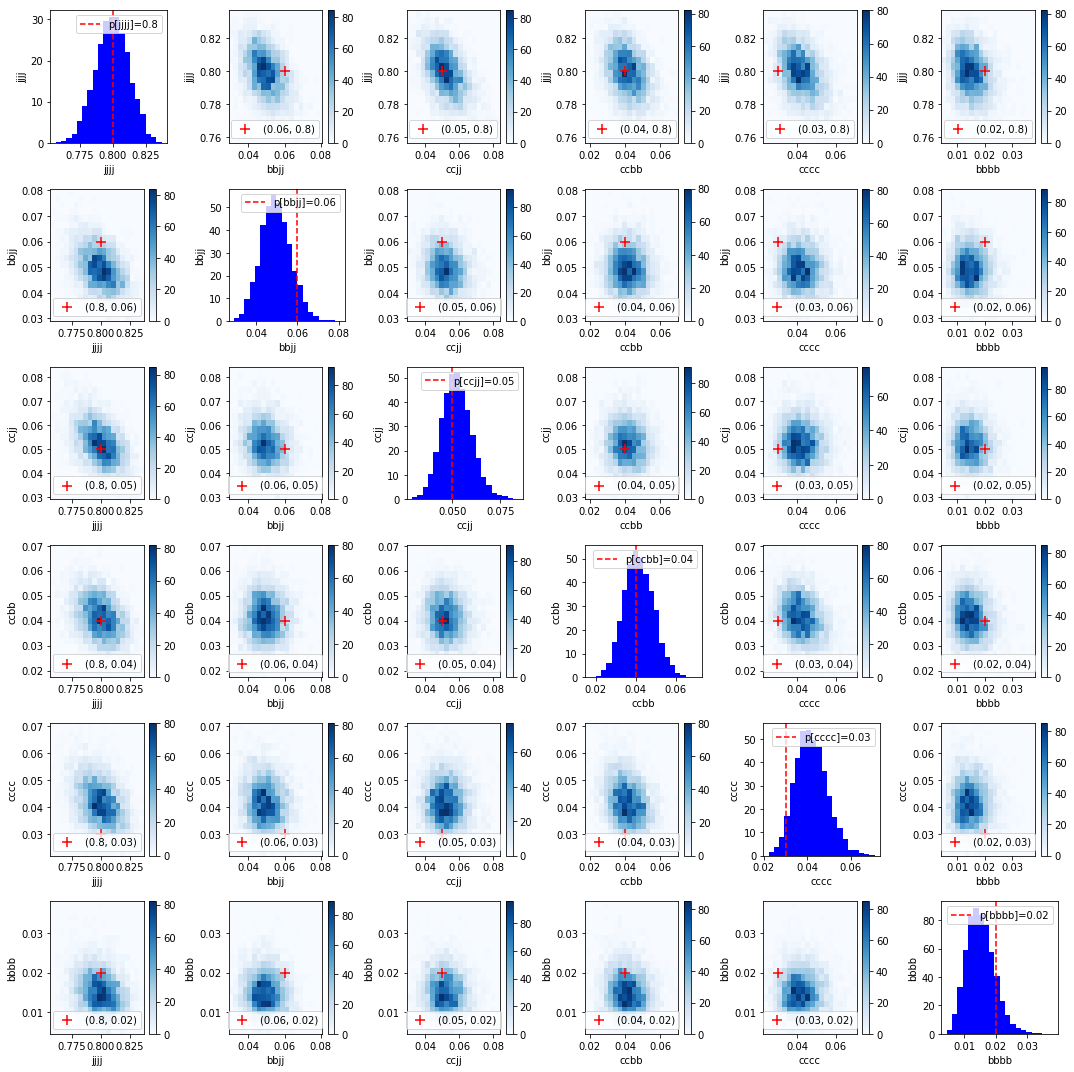

In [42]:
# Assuming df_4d contains your theta.1 to theta.6 columns
mydata = df_4d[['theta.1', 'theta.2', 'theta.3', 'theta.4', 'theta.5', 'theta.6']]

# Initialize the subplot grid
fig, axes = plt.subplots(6, 6, figsize=(15, 15))

# Loop through each subplot and create scatter plots or histograms
for i in range(6):
    for j in range(6):
        if i == j:
            # Plot a histogram on the diagonal
            axes[i, j].hist(mydata.iloc[:, i], bins=20, color='blue',density=True)
            axes[i, j].axvline(p[i], color='red', linestyle='--', label=f'p[{classes[i]}]={p[i]}')
            axes[i, j].set_ylabel(f'{classes[i]}')
            axes[i, j].set_xlabel(f'{classes[i]}')
            axes[i, j].legend()
        else:
            # 2D Histogram for off-diagonal combinations
            h = axes[i, j].hist2d(mydata.iloc[:, j], mydata.iloc[:, i], bins=20, cmap='Blues')
            # Add a red cross at the real value position (p[j], p[i])
            axes[i, j].scatter(p[j], p[i], color='red', marker='+', s=100, label=f'({p[j]}, {p[i]})')
            axes[i, j].set_xlabel(f'{classes[j]}')
            axes[i, j].set_ylabel(f'{classes[i]}')
            axes[i, j].legend(loc='lower center')
            # Add a color bar for the density
            fig.colorbar(h[3], ax=axes[i, j])

# Adjust layout
plt.tight_layout()
plt.show()

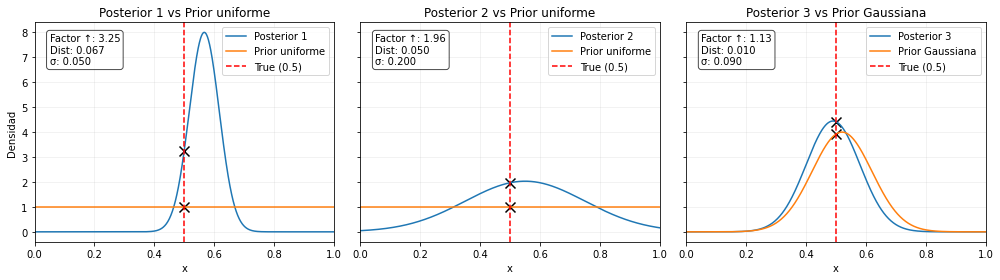

In [36]:
import numpy as np
import matplotlib.pyplot as plt

# Parámetros comunes
true_value = 0.5

# Posterior 1
mu1, sigma1 = 0.567, 0.05

# Posterior 2
mu2, sigma2 = 0.55, 0.2

# Posterior 3
mu3, sigma3 = 0.49, 0.09

# Prior 3 (Gaussiana)
mu_prior3, sigma_prior3 = 0.52, 0.1

# Crear valores de x en [0,1]
x = np.linspace(0, 1, 1000)

# Función para crear PDF normalizada en [0,1]
def normalized_pdf(mu, sigma):
    pdf = 1/(sigma * np.sqrt(2*np.pi)) * np.exp(-0.5 * ((x - mu)/sigma)**2)
    return pdf / np.trapz(pdf, x)

# PDFs normalizadas
post1 = normalized_pdf(mu1, sigma1)
post2 = normalized_pdf(mu2, sigma2)
post3 = normalized_pdf(mu3, sigma3)

# Prior uniforme para los primeros dos subplots
prior_uniform = np.ones_like(x)
prior_uniform /= np.trapz(prior_uniform, x)

# Prior gaussiana para el tercer subplot
prior3 = normalized_pdf(mu_prior3, sigma_prior3)

# Valores en el punto verdadero
y_post1 = np.interp(true_value, x, post1)
y_post2 = np.interp(true_value, x, post2)
y_post3 = np.interp(true_value, x, post3)

y_prior_uniform = np.interp(true_value, x, prior_uniform)
y_prior3 = np.interp(true_value, x, prior3)

# Cálculo de factores y distancias
factor1 = y_post1 / y_prior_uniform
factor2 = y_post2 / y_prior_uniform
factor3 = y_post3 / y_prior3

dist1 = abs(mu1 - true_value)
dist2 = abs(mu2 - true_value)
dist3 = abs(mu3 - true_value)

# Crear subplots
fig, axes = plt.subplots(1, 3, figsize=(14, 4), sharey=True)

# Subplot 1: Posterior 1 + Prior uniforme
axes[0].plot(x, post1, label='Posterior 1')
axes[0].plot(x, prior_uniform, label='Prior uniforme')
axes[0].axvline(true_value, color='red', linestyle='--', label='True (0.5)')
axes[0].scatter([true_value]*2, [y_post1, y_prior_uniform], marker='x', s=100, color='black')
axes[0].set_title('Posterior 1 vs Prior uniforme')
axes[0].set_xlim(0, 1)
axes[0].set_xlabel('x')
axes[0].set_ylabel('Densidad')
axes[0].grid(alpha=0.2)
axes[0].legend()
axes[0].text(0.05, 0.95,
             f"Factor ↑: {factor1:.2f}\nDist: {dist1:.3f}\nσ: {sigma1:.3f}",
             transform=axes[0].transAxes, va='top', ha='left',
             bbox=dict(boxstyle="round,pad=0.3", facecolor="white", alpha=0.7))

# Subplot 2: Posterior 2 + Prior uniforme
axes[1].plot(x, post2, label='Posterior 2')
axes[1].plot(x, prior_uniform, label='Prior uniforme')
axes[1].axvline(true_value, color='red', linestyle='--', label='True (0.5)')
axes[1].scatter([true_value]*2, [y_post2, y_prior_uniform], marker='x', s=100, color='black')
axes[1].set_title('Posterior 2 vs Prior uniforme')
axes[1].set_xlim(0, 1)
axes[1].set_xlabel('x')
axes[1].grid(alpha=0.2)
axes[1].legend()
axes[1].text(0.05, 0.95,
             f"Factor ↑: {factor2:.2f}\nDist: {dist2:.3f}\nσ: {sigma2:.3f}",
             transform=axes[1].transAxes, va='top', ha='left',
             bbox=dict(boxstyle="round,pad=0.3", facecolor="white", alpha=0.7))

# Subplot 3: Posterior 3 + Prior gaussiana
axes[2].plot(x, post3, label='Posterior 3')
axes[2].plot(x, prior3, label='Prior Gaussiana')
axes[2].axvline(true_value, color='red', linestyle='--', label='True (0.5)')
axes[2].scatter([true_value]*2, [y_post3, y_prior3], marker='x', s=100, color='black')
axes[2].set_title('Posterior 3 vs Prior Gaussiana')
axes[2].set_xlim(0, 1)
axes[2].set_xlabel('x')
axes[2].grid(alpha=0.2)
axes[2].legend()
axes[2].text(0.05, 0.95,
             f"Factor ↑: {factor3:.2f}\nDist: {dist3:.3f}\nσ: {sigma3:.3f}",
             transform=axes[2].transAxes, va='top', ha='left',
             bbox=dict(boxstyle="round,pad=0.3", facecolor="white", alpha=0.7))

plt.tight_layout()
plt.show()
